# Polygon Vectorization and Adjacency Graph Construction

This notebook processes raw polygon data extracted from the previous step to establish geometric consistency, calculate key architectural features (such as area, perimeter, centroid, bounding box, aspect ratio, and orientation), and map spatial relationships between walls. 

- [Geometry Cleanup and Refinement](#cleanup-section) – Simplify boundaries and remove artifacts.
- [Feature Extraction](#feature-section) – Compute physical properties for each wall segment.
- [Corner and Angle Analysis](#angle-section) – Detect orthogonal and diagonal corner structures.
- [Wall Snapping](#snapping-section) – Align segments.
- [Graph Extraction](#graph-section) – Establish adjacency using bounding box overlap and save the result.


In [1]:
import sys
from pathlib import Path
import cv2
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from src.visualization import plot_polygons
from src.io_utils import save_json

## <a id="cleanup-section"></a>Geometry Cleanup and Refinement

### Loading Raw Polygons

We load the contour-based polygons obtained from the segmentation step.

They are not yet geometrically reliable and may contain pixel-level jaggedness, duplicate vertices, unclosed loops, or collinear points that bloat the feature space. We need to clean them before analyzing or vectorizing.


In [2]:
with open("../output/polygons.pkl", "rb") as f:
    polygons = pickle.load(f)

### Normalization

We reshape the raw contours (ensuring a standard shape of `(N, 2)`) and cast their coordinates to floating-point values for precise geometric computations.


In [3]:
def normalize_polygon(poly):
    poly = np.array(poly)

    # Case: (N, 1, 2) → (N, 2)
    if len(poly.shape) == 3 and poly.shape[1] == 1:
        poly = poly.reshape(-1, 2)

    # Case: (N, 2, 1) or similar weird cases
    if len(poly.shape) == 3 and poly.shape[-1] == 1:
        poly = poly.reshape(-1, 2)

    # Ensure float
    poly = poly.astype(np.float32)

    return poly

### Deduplicating Points

During contour detection, duplicate or nearly identical consecutive points can be generated. We remove them to ensure that polygons have a clean structure.


In [4]:
def remove_duplicate_points(poly):
    cleaned = [poly[0]]
    for p in poly[1:]:
        if not np.allclose(p, cleaned[-1]):
            cleaned.append(p)
    return cleaned

### Enforcing Closed Polygons

For subsequent computations (such as area and perimeter), the polygon is required to form a closed loop, meaning the last vertex exactly matches the first vertex.


In [5]:
def ensure_closed(poly):
    if not np.allclose(poly[0], poly[-1]):
        poly = poly + [poly[0]]
    return poly

### Removing Near-Collinear Points


To simplify the boundary representations and remove jagged segmentation artifacts, we filter out vertices that are collinear (or nearly collinear) with their immediate neighbors. 

Collinearity is determined by computing the 2D cross product of the two vectors meeting at each vertex. If the cross product magnitude is below a tiny threshold $\epsilon$, the middle vertex is redundant and can be safely removed.


In [6]:
def is_collinear(p1, p2, p3, eps=1e-3):
    p1 = np.array(p1, dtype=np.float32)
    p2 = np.array(p2, dtype=np.float32)
    p3 = np.array(p3, dtype=np.float32)

    v1 = p2 - p1
    v2 = p3 - p2

    # 2D cross product (scalar)
    cross = v1[0] * v2[1] - v1[1] * v2[0]

    return abs(cross) < eps

def remove_collinear(poly):
    if len(poly) < 3:
        return poly

    cleaned = [poly[0]]
    for i in range(1, len(poly)-1):
        if not is_collinear(poly[i-1], poly[i], poly[i+1]):
            cleaned.append(poly[i])
    cleaned.append(poly[-1])
    return cleaned

### Comprehensive Cleanup Pipeline

We combine normalization, removing duplicates, closure enforcement, and collinear point removal into a single cleanup pipeline.


In [7]:
def clean_polygon(poly):
    poly = normalize_polygon(poly)
    poly = remove_duplicate_points(poly)
    poly = ensure_closed(poly)
    poly = remove_collinear(poly)
    return poly

In [8]:
cleaned_polygons = [clean_polygon(p) for p in polygons]

## <a id="feature-section"></a>Feature Extraction


### Area Computation

Calculate the area of the polygon using the Shoelace formula (also known as Gauss's area formula).

This indicates the physical footprint of the wall element.

In [9]:
def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]

    return 0.5 * (
        np.dot(x, np.roll(y, -1))
        - np.dot(y, np.roll(x, -1))
    )

In [10]:
def polygon_area(poly):
    return abs(polygon_signed_area(poly))

### Perimeter Computation


Calculate the sum of Euclidean distances between successive vertices. The perimeter is a useful feature to distinguish long structural walls from small noise blobs or doors/windows.


In [11]:
def polygon_perimeter(poly):
    diff = np.roll(poly, -1, axis=0) - poly
    return np.sum(np.linalg.norm(diff, axis=1))

### Centroid Computation


Compute the geometric center (center of mass) of each polygon. The centroid coordinates serve as a reference point for calculating distances between walls and constructing spatial adjacency graphs.


In [12]:
def polygon_centroid(poly):
    x = poly[:, 0]
    y = poly[:, 1]

    a = polygon_signed_area(poly)
    if a == 0:
        return np.mean(poly, axis=0)

    factor = (x * np.roll(y, -1) - y * np.roll(x, -1))
    cx = np.sum((x + np.roll(x, -1)) * factor) / (6 * a)
    cy = np.sum((y + np.roll(y, -1)) * factor) / (6 * a)

    return np.array([cx, cy])

### Axis-Aligned Bounding Box (AABB)


Determine the minimum and maximum coordinates along each axis to obtain the bounding box. The bounding box is crucial for fast spatial filtering, collision detection, and overlap checks.


In [13]:
def polygon_bbox(poly):
    x_min = np.min(poly[:, 0])
    y_min = np.min(poly[:, 1])
    x_max = np.max(poly[:, 0])
    y_max = np.max(poly[:, 1])

    return np.array([x_min, y_min, x_max, y_max])

### Aspect Ratio


Compute the aspect ratio of the bounding box. Wall segments typically exhibit highly elongated shapes (high or low aspect ratio), while columns, rooms, or noise artifacts tend to be more square-like or balanced (aspect ratio close to 1).


In [14]:
def aspect_ratio(bbox):
    x_min, y_min, x_max, y_max = bbox
    w = x_max - x_min
    h = y_max - y_min

    if h == 0:
        return 0
    return w / h

### Orientation Estimation


Estimate the main orientation of the polygon using Principal Component Analysis (PCA) on its vertices. Compute the covariance matrix of the centered coordinates and extract the eigenvector corresponding to the largest eigenvalue. This eigenvector points in the direction of maximum variance, representing the dominant orientation of the wall.


In [15]:
def polygon_orientation(poly):
    poly = np.array(poly, dtype=np.float32)

    centered = poly - np.mean(poly, axis=0)

    cov = np.cov(centered.T)

    eigvals, eigvecs = np.linalg.eig(cov)

    # Force real values
    eigvals = np.real(eigvals)
    eigvecs = np.real(eigvecs)

    main_axis = eigvecs[:, np.argmax(eigvals)]

    # Force scalar floats
    x = float(main_axis[0])
    y = float(main_axis[1])

    angle = np.arctan2(y, x)

    return np.degrees(angle)

### Combined Feature Extraction

Combine all the individual feature extraction functions into a single dictionary for convenience.


In [16]:
def extract_features(poly):
        
    bbox = polygon_bbox(poly)

    return {
        "area": polygon_area(poly),
        "perimeter": polygon_perimeter(poly),
        "centroid": polygon_centroid(poly),
        "bbox": bbox,
        "aspect_ratio": aspect_ratio(bbox),
        "orientation": polygon_orientation(poly),
        "num_vertices": len(poly)
    }

### Extracting Features for the Dataset

Extract features for all cleaned polygons and construct a Pandas DataFrame for analysis.


In [17]:
cleaned_polygons = [np.array(p, dtype=np.float32) for p in cleaned_polygons]

In [18]:
features = [extract_features(p) for p in cleaned_polygons]

In [19]:
df = pd.DataFrame(features)
df.head()

,area,perimeter,centroid,bbox,aspect_ratio,orientation,num_vertices
0,3925.0,540.288513,"[295.24384, 401.56772]","[173.0, 382.0, 412.0, 410.0]",8.535714,-2.266214,11
1,5607.5,1102.647461,"[343.26938, 226.92436]","[231.0, 101.0, 412.0, 360.0]",0.698842,-117.427228,15
2,6174.5,1284.167969,"[135.67609, 253.01001]","[110.0, 101.0, 194.0, 410.0]",0.271845,-85.622470,21


## <a id="angle-section"></a>Angle Detection and Classification


To analyze the geometry of the floorplan, inspect the interior/corner angles at each vertex. Detect right angles (90°) and diagonal corners (45° or 135°), which represent structural corners, while identifying noise or collinear vertices.


### Angle Between Three Points

Calculate the angle at vertex $p_2$ formed by vectors $v_1 = p_1 - p_2$ and $v_2 = p_3 - p_2$ using the dot product formula:
$$\cos \theta = \frac{v_1 \cdot v_2}{\|v_1\| \|v_2\|}$$


In [20]:
def angle_between(p1, p2, p3):
    p1, p2, p3 = map(lambda x: np.array(x, dtype=np.float32), [p1, p2, p3])

    v1 = p1 - p2
    v2 = p3 - p2

    cos_theta = np.dot(v1, v2) / (
        np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8
    )

    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
    return angle

### Detect Structural Corners (45°, 90°, 135°)

Modify corner detector to look for structural angles, including orthogonal (90°) and diagonal angles (45° and 135°), which are common in non-standard floor plans.


In [21]:
def detect_structural_angles(poly, tol=10):
    poly = np.array(poly, dtype=np.float32)

    angles = []
    for i in range(len(poly)):
        p1 = poly[i - 1]
        p2 = poly[i]
        p3 = poly[(i + 1) % len(poly)]

        angle = angle_between(p1, p2, p3)

        # Check if the angle is near 45, 90, or 135 degrees
        if any(abs(angle - target) <= tol for target in [45, 90, 135]):
            angles.append((i, angle))

    return angles


In [22]:
all_angles = []

for poly in cleaned_polygons:
    angles = detect_structural_angles(poly)
    all_angles.append(angles)


In [23]:
def classify_angle(angle, tol=5):
    if abs(angle - 90) <= tol:
        return "RIGHT_ANGLE"
    elif abs(angle - 45) <= tol:
        return "ACUTE_45"
    elif abs(angle - 135) <= tol:
        return "OBTUSE_135"
    elif abs(angle - 180) <= tol:
        return "STRAIGHT"
    else:
        return "NOISE"


In [24]:
classified_angles = []

for poly_angles in all_angles:
    c = [(i, ang, classify_angle(ang)) for i, ang in poly_angles]
    classified_angles.append(c)

### Angle Distribution Visualization

We plot a histogram of the detected structural angles to check their distribution across the floorplan.


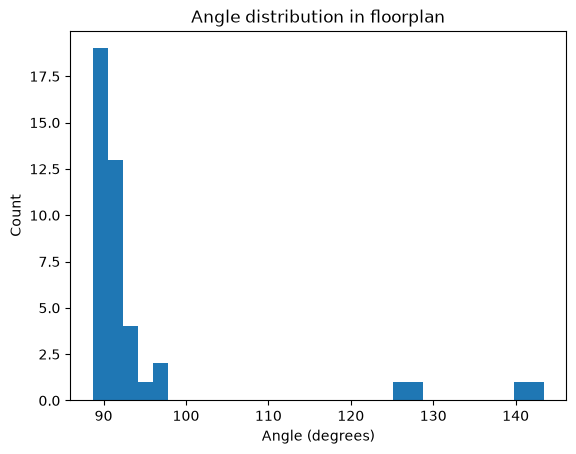

In [25]:
flat_angles = [
    ang for poly in all_angles for _, ang in poly
]

plt.hist(flat_angles, bins=30)
plt.title("Angle distribution in floorplan")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.show()

In [26]:
def wall_quality(poly_angles, tol=10):
    total = len(poly_angles)
    if total == 0:
        return 0

    # Quality is determined by the ratio of structural corners (45°, 90°, 135°) to total corners
    good = sum(
        1 for _, ang in poly_angles
        if any(abs(ang - target) <= tol for target in [45, 90, 135])
    )

    return good / total


## <a id="snapping-section"></a>Wall Snapping and Vectorization


Now align the wall segments to clean directional vectors. Instead of forcing all edges to be strictly orthogonal (0° or 90°), support diagonal walls by snapping edge angles to the nearest multiple of 45° (i.e., 0°, 45°, 90°, 135°, etc.). This ensures that diagonal walls are preserved and not distorted into stair-step vertical/horizontal segments.

After snapping sequential segments, the polygon is properly closed by linking the final vertex back to the start vertex.


### Computing Edge Direction

Compute the angle (in degrees) of the directed segment from $p_1$ to $p_2$ using `arctan2`.


In [27]:
def edge_angle(p1, p2):
    delta = np.array(p2) - np.array(p1)
    return np.degrees(np.arctan2(delta[1], delta[0]))

### Snapping to 45-degree Grid

Round edge angles to the nearest multiple of 45° to support diagonal features.


In [28]:
def snap_to_45_selective(angle, tolerance=8):
    # Normalize angle to [-180, 180] range
    angle = (angle + 180) % 360 - 180
    
    target = round(angle / 45) * 45
    diff = abs(angle - target)
    if diff > 180:
        diff = 360 - diff
        
    if diff <= tolerance:
        return target
    return angle


### Reconstructing Snapped Polygons

Reconstruct each polygon by walking along its edges, snapping the direction of each edge, and computing new vertex coordinates. Finally, close the polygon loop.


In [29]:
def snap_polygon_to_grid(poly, tolerance=8):
    poly = np.array(poly, dtype=np.float32)
    N = len(poly)
    if N < 3:
        return poly

    snapped = poly.copy()

    for i in range(N - 1):
        p1 = poly[i]
        p2 = poly[i + 1]

        angle = edge_angle(p1, p2)
        snapped_angle = snap_to_45_selective(angle, tolerance)

        length = np.linalg.norm(p2 - p1)

        direction = np.array([
            np.cos(np.radians(snapped_angle)),
            np.sin(np.radians(snapped_angle))
        ])

        snapped[i + 1] = snapped[i] + direction * length

    # Distribute the closure error evenly across all vertices to prevent shearing
    closure_error = snapped[-1] - snapped[0]
    
    adjusted = snapped.copy()
    for i in range(1, N):
        adjusted[i] = snapped[i] - (i / (N - 1)) * closure_error

    # Force the last vertex to be exactly equal to the first
    adjusted[-1] = adjusted[0]

    return adjusted


Snap only structurally valid walls.


In [30]:
snapped_polygons = []

for poly, angles in zip(cleaned_polygons, all_angles):

    quality = wall_quality(angles)

    if quality > 0.6:
        snapped = snap_polygon_to_grid(poly)
    else:
        snapped = poly  # keep original

    snapped_polygons.append(snapped)


### Angle Comparison Visualization

Visualize the edge angle distribution before and after snapping to see how they align to the 45-degree grid.


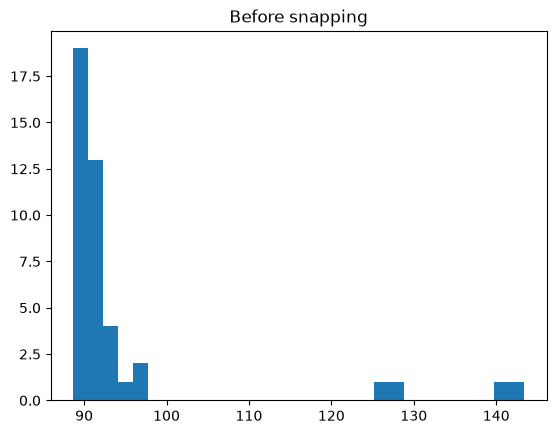

In [31]:
plt.hist(flat_angles, bins=30)
plt.title("Before snapping")
plt.show()

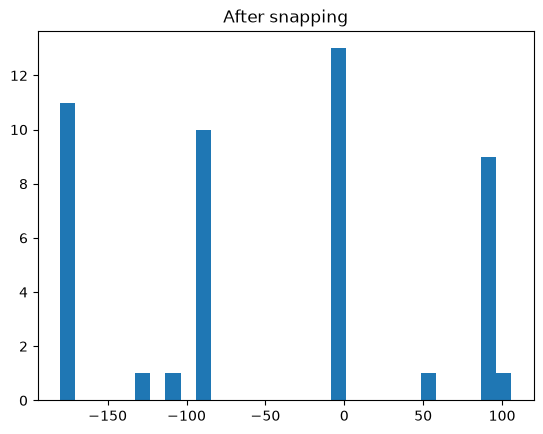

In [32]:
snapped_angles = []

for poly in snapped_polygons:
    snapped_angles.extend([
        edge_angle(poly[i], poly[(i+1)%len(poly)])
        for i in range(len(poly))
    ])

plt.hist(snapped_angles, bins=30)
plt.title("After snapping")
plt.show()

## <a id="graph-section"></a>Graph Extraction

In [33]:
wall_data = []

for i, poly in enumerate(cleaned_polygons):
    feat = extract_features(poly)
    feat["id"] = i
    wall_data.append(feat)

### Distance Metrics

Define the distance between two wall segments based on their centroids.


In [34]:
def centroid_dist(a, b):
    return np.linalg.norm(a["centroid"] - b["centroid"])

### Building Adjacency Graph (Centroid Method)

Build an adjacency graph linking walls that are close to one another based on centroid distance.


In [35]:
edges = []

DIST_THRESHOLD = 50  # tuned based on image scale

for i in range(len(wall_data)):
    for j in range(i + 1, len(wall_data)):

        d = centroid_dist(wall_data[i], wall_data[j])

        if d < DIST_THRESHOLD:
            edges.append((i, j))

### Building Adjacency Graph (Bounding Box Method)


Centroid-based distance can link far-away walls if they are large, or miss close ones. Bounding box intersection is much more robust to establish connectivity between overlapping or touching wall segments.


In [36]:
def bbox_intersect(a, b):
    ax1, ay1, ax2, ay2 = a["bbox"]
    bx1, by1, bx2, by2 = b["bbox"]

    return not (ax2 < bx1 or bx2 < ax1 or ay2 < by1 or by2 < ay1)

In [37]:
edges = []

for i in range(len(wall_data)):
    for j in range(i + 1, len(wall_data)):

        if bbox_intersect(wall_data[i], wall_data[j]):
            edges.append((i, j))

### Structuring the Final Graph


In [38]:
graph = {
    "nodes": wall_data,
    "edges": edges
}

### Exporting Graph to JSON

Serialize wall connectivity graph to a JSON file so it can be used for downstream tasks (like room segmentation or vector model generation).


In [39]:
def make_json_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, np.floating):
        return float(obj)

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [make_json_serializable(i) for i in obj]

    return obj

In [41]:
clean_graph = make_json_serializable(graph)

save_json(clean_graph, "../output/wall_graph.json")

### Visualizing the Resulting Polygons

Plot the polygons before and after snapping to visually verify the alignment.


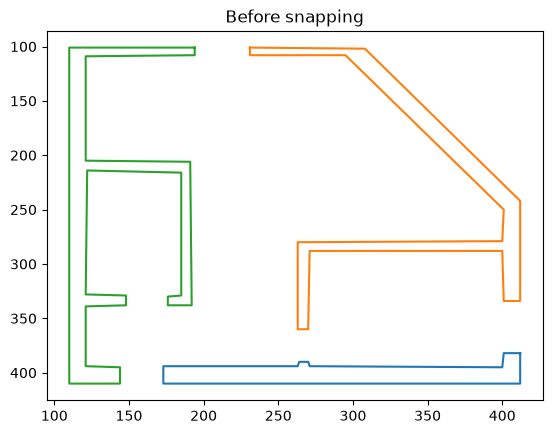

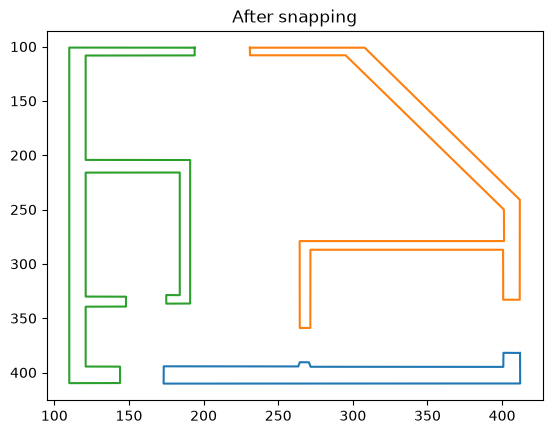

In [ ]:
plot_polygons(cleaned_polygons, "Before snapping")
plot_polygons(snapped_polygons, "After snapping")
